# Exploración y generación de datos sintéticos con la librería `andi_datasets`

## Objetivo del cuaderno

El objetivo de este cuaderno es realizar una primera toma de contacto con la librería `andi_datasets`, con el fin de comprender cómo se generan trayectorias sintéticas asociadas a procesos de difusión anómala.

En particular, se pretende:

1. cargar y utilizar la librería `andi_datasets`,
2. analizar el mecanismo de generación de datos a partir de modelos estocásticos,
3. estudiar la influencia del exponente anómalo en la dinámica de las trayectorias,
4. realizar experimentos numéricos sencillos que permitan interpretar el comportamiento de los datos,
5. construir ejemplos básicos relacionados con problemas de segmentación de trayectorias.


In [4]:
# Descomentar la siguiente línea en caso de no tener instalada la librería
# !pip install andi-datasets

# Importación de librerías

import numpy as np
import matplotlib.pyplot as plt
from andi_datasets.datasets_theory import datasets_theory

# Configuración de visualización

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 1. Generación de datos sintéticos

La librería `andi_datasets` proporciona herramientas para simular trayectorias asociadas a distintos modelos de difusión anómala.

En particular, la clase `datasets_theory()` permite generar datos sintéticos a partir de modelos estocásticos bien definidos, como CTRW, FBM o SBM, entre otros.

Estos datos constituyen la base del análisis posterior, ya que permiten estudiar de forma controlada el comportamiento de distintos procesos de difusión, así como evaluar métodos de caracterización y segmentación de trayectorias.

In [2]:
dataset = datasets_theory()

## 2. Primera prueba: generación de una trayectoria

En esta sección se genera una trayectoria sintética simple utilizando la librería `andi_datasets`.

Se consideran los siguientes parámetros:

- longitud de la trayectoria: $T = 100$,
- un único modelo estocástico,
- exponente de difusión: $\alpha = 1$,
- modelo seleccionado: FBM (Fractional Brownian Motion), correspondiente a `models=[2]`.

Este ejemplo permite verificar el correcto funcionamiento del generador y analizar la estructura de los datos obtenidos.

In [3]:
traj = dataset.create_dataset(
    T=100,
    N_models=1,
    exponents=[1],
    models=[2]
)

traj.shape

(1, 102)

In [16]:
traj[0, :10]

array([ 2.        ,  1.        ,  0.        , -0.12488308, -0.32568061,
       -0.40826457, -0.48715814, -0.43940819, -0.24449769, -0.09959711])

### Interpretación de la estructura de los datos

La salida generada por la función `create_dataset` presenta una estructura matricial en la que cada fila corresponde a una trayectoria simulada junto con sus parámetros asociados.

En particular, para una trayectoria dada se tiene:

- `traj[0, 0]`: identificador del modelo estocástico utilizado,
- `traj[0, 1]`: valor del exponente de difusión $\alpha$,
- `traj[0, 2:]`: valores de la trayectoria $x(t)$ en función del tiempo.

Esta organización permite disponer simultáneamente de la información del modelo, del parámetro dinámico y de la señal observada, lo cual resulta fundamental para tareas posteriores de análisis y clasificación.

In [17]:
model_id = traj[0, 0]
alpha = traj[0, 1]
x = traj[0, 2:]

print("Modelo:", model_id)
print("Alpha:", alpha)
print("Longitud de la trayectoria:", len(x))

Modelo: 2.0
Alpha: 1.0
Longitud de la trayectoria: 100


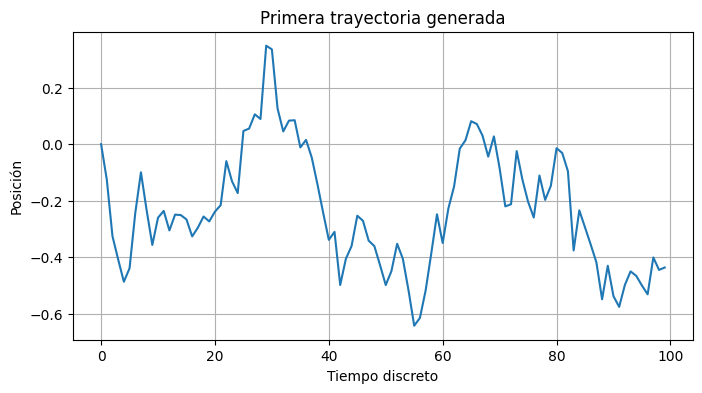

In [18]:
plt.plot(x)
plt.title("Primera trayectoria generada")
plt.xlabel("Tiempo discreto")
plt.ylabel("Posición")
plt.show()

## 3. Función para calcular la MSD empírica

Para analizar la trayectoria, calculamos la mean squared displacement (MSD) empírica.

In [19]:
def empirical_msd(x, max_lag=None):
    x = np.asarray(x)
    n = len(x)

    if max_lag is None:
        max_lag = n // 4

    lags = np.arange(1, max_lag + 1)
    msd_vals = []

    for lag in lags:
        diffs = x[lag:] - x[:-lag]
        msd_vals.append(np.mean(diffs**2))

    return lags, np.array(msd_vals)

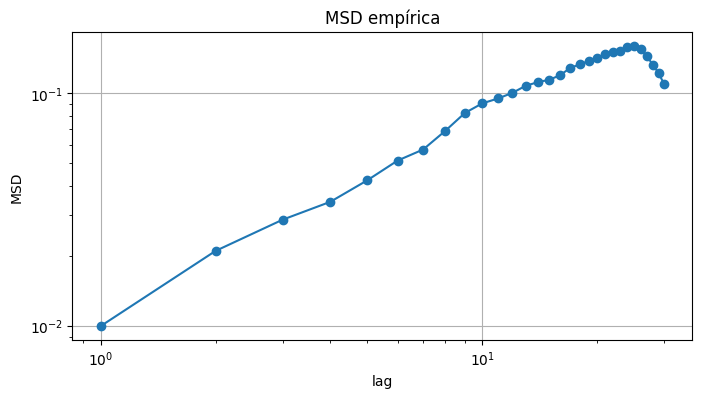

In [20]:
lags, msd_vals = empirical_msd(x, max_lag=30)

plt.loglog(lags, msd_vals, 'o-')
plt.title("MSD empírica")
plt.xlabel("lag")
plt.ylabel("MSD")
plt.show()

## 4. Prueba 1: efecto del exponente \($\alpha$\)

Mantenemos el mismo modelo (FBM) y cambiamos el valor de \($\alpha$\).

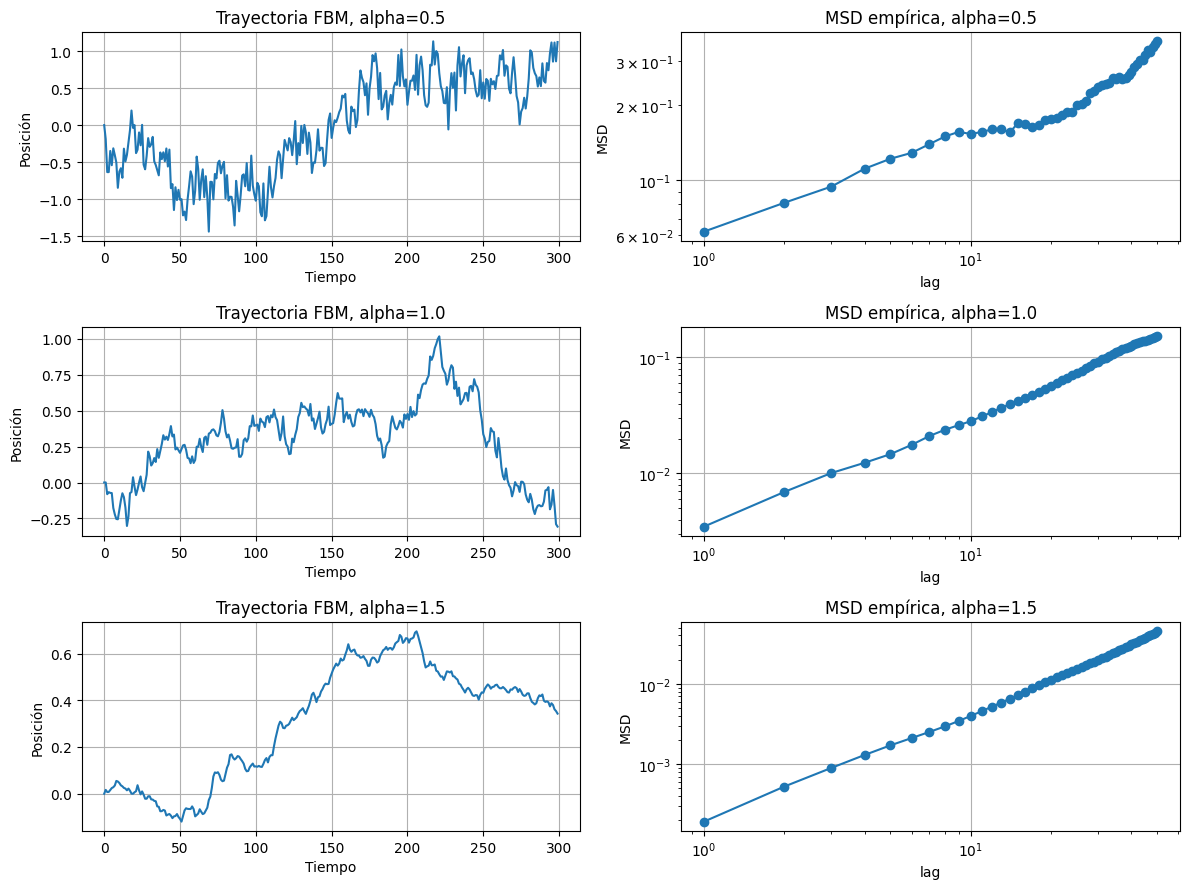

In [21]:
alphas = [0.5, 1.0, 1.5]

fig, axes = plt.subplots(len(alphas), 2, figsize=(12, 9))

for i, a in enumerate(alphas):
    traj = dataset.create_dataset(
        T=300,
        N_models=1,
        exponents=[a],
        models=[2]
    )
    x = traj[0, 2:]

    axes[i, 0].plot(x)
    axes[i, 0].set_title(f"Trayectoria FBM, alpha={a}")
    axes[i, 0].set_xlabel("Tiempo")
    axes[i, 0].set_ylabel("Posición")

    lags, msd_vals = empirical_msd(x, max_lag=50)
    axes[i, 1].loglog(lags, msd_vals, 'o-')
    axes[i, 1].set_title(f"MSD empírica, alpha={a}")
    axes[i, 1].set_xlabel("lag")
    axes[i, 1].set_ylabel("MSD")

plt.tight_layout()
plt.show()

### Comentario

Los resultados obtenidos ponen de manifiesto que el exponente anómalo $\alpha$ controla directamente la dinámica de difusión, ya que determina la ley de escalado temporal de la desviación cuadrática media (MSD), $\mathrm{MSD}(t) \sim t^\alpha$.

En particular, se distinguen tres regímenes bien definidos:

- $\alpha < 1$: régimen subdifusivo, caracterizado por una dispersión lenta de la partícula, típicamente asociada a efectos de atrapamiento, heterogeneidad del medio o memoria en el proceso dinámico.

- $\alpha \approx 1$: régimen de difusión normal (browniana), en el que la MSD crece linealmente con el tiempo, reflejando un proceso markoviano sin correlaciones temporales.

- $\alpha > 1$: régimen superdifusivo, donde la dispersión es más rápida que en el caso browniano, lo que indica la presencia de correlaciones positivas o eventos de gran desplazamiento, como en procesos tipo Lévy.

Además, el análisis conjunto de las trayectorias y sus correspondientes MSD confirma la coherencia entre la dinámica microscópica y el comportamiento estadístico macroscópico. En particular, se observa que trayectorias más erráticas y confinadas corresponden a exponentes subdifusivos, mientras que trayectorias más persistentes y direccionales se asocian a regímenes superdifusivos.


## 5. Prueba 2: comparar distintos modelos con el mismo $\alpha$

Ahora fijamos $\alpha = 1$ y cambiamos el modelo.

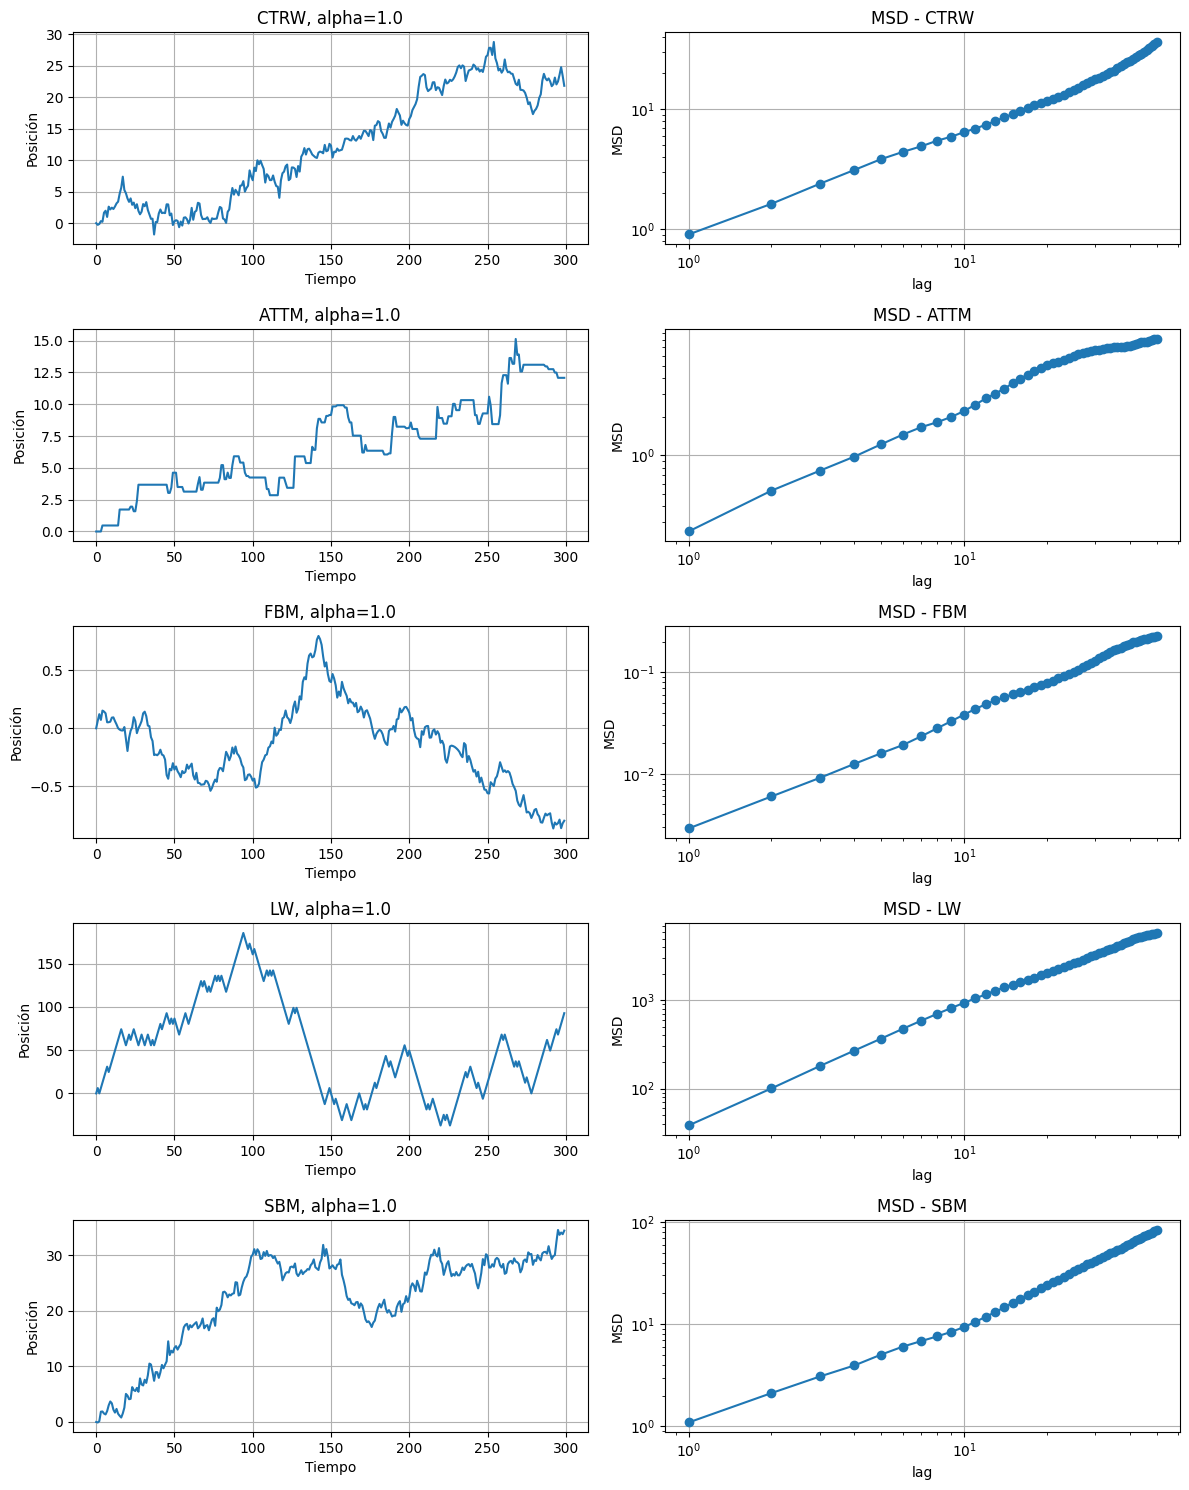

In [27]:
model_dict = {
    0: "CTRW",
    1: "ATTM",
    2: "FBM",
    3: "LW",
    4: "SBM"
}

models_to_test = [0, 1, 2, 3, 4]
alpha_fixed = 1.0

fig, axes = plt.subplots(len(models_to_test), 2, figsize=(12, 15))

for i, m in enumerate(models_to_test):
    traj = dataset.create_dataset(
        T=300,
        N_models=1,
        exponents=[alpha_fixed],
        models=[m]
    )
    x = traj[0, 2:]

    axes[i, 0].plot(x)
    axes[i, 0].set_title(f"{model_dict[m]}, alpha={alpha_fixed}")
    axes[i, 0].set_xlabel("Tiempo")
    axes[i, 0].set_ylabel("Posición")

    lags, msd_vals = empirical_msd(x, max_lag=50)
    axes[i, 1].loglog(lags, msd_vals, 'o-')
    axes[i, 1].set_title(f"MSD - {model_dict[m]}")
    axes[i, 1].set_xlabel("lag")
    axes[i, 1].set_ylabel("MSD")

plt.tight_layout()
plt.show()

## Análisis comparativo de modelos de difusión anómala

La figura anterior presenta, para distintos modelos estocásticos (CTRW, ATTM, FBM, LW y SBM), dos elementos fundamentales:
- a la izquierda: una trayectoria simulada $x(t)$,
- a la derecha: la MSD (mean squared displacement) empírica en escala log-log.

### 1. Comportamiento global

Se observa que, a pesar de las diferencias en las trayectorias, todas las curvas de MSD siguen aproximadamente una ley de tipo potencia:

$$
\mathrm{MSD}(t) = \left\langle (x(t)-x(0))^2 \right\rangle \propto t^\alpha
$$

En este caso, el valor de $\alpha = 1$ se ha fijado para todos los modelos, lo que explica que las pendientes en las representaciones log-log sean similares.

---

### 2. Diferencias entre modelos

Sin embargo, las trayectorias muestran comportamientos cualitativamente distintos:

- **CTRW**: se observan periodos de inmovilidad (tiempos de espera), característicos de procesos no ergódicos.
- **ATTM**: presenta cambios en la difusividad a lo largo del tiempo, lo que genera trayectorias heterogéneas.
- **FBM**: muestra una trayectoria más suave debido a la correlación entre los incrementos.
- **LW**: aparecen desplazamientos largos, asociados a una dinámica con saltos.
- **SBM**: la difusión depende explícitamente del tiempo, modificando progresivamente el comportamiento.

---

### 3. Conclusión

Este análisis permite concluir que:

- la librería genera trayectorias sintéticas coherentes con distintos modelos de difusión anómala,
- la ley $\mathrm{MSD} \sim t^\alpha$ es una propiedad común,
- sin embargo, la dinámica microscópica depende del modelo.

Este tipo de exploración constituye un paso fundamental antes de aplicar métodos automáticos de segmentación para resolver la Task 3.

## 6. Construcción manual de una trayectoria tipo Task 3

La **Task 3** consiste en estudiar trayectorias con un **changepoint**, es decir, un cambio de régimen dentro de la misma trayectoria. El objetivo es localizar el cambio y caracterizar los dos segmentos.

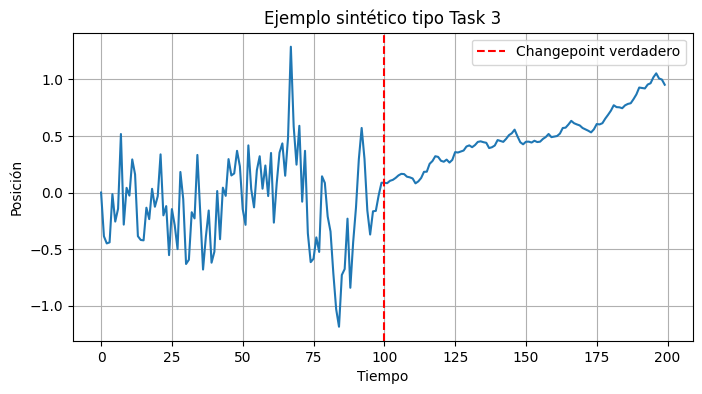

In [28]:
traj1 = dataset.create_dataset(
    T=100,
    N_models=1,
    exponents=[0.5],
    models=[2]
)

traj2 = dataset.create_dataset(
    T=100,
    N_models=1,
    exponents=[1.5],
    models=[2]
)

x1 = traj1[0, 2:]
x2 = traj2[0, 2:]

# Ajuste simple para conectar visualmente ambos segmentos
x2_shifted = x2 - x2[0] + x1[-1]

x_task3 = np.concatenate([x1, x2_shifted])
cp_true = len(x1)

plt.plot(x_task3)
plt.axvline(cp_true, color="red", linestyle="--", label="Changepoint verdadero")
plt.title("Ejemplo sintético tipo Task 3")
plt.xlabel("Tiempo")
plt.ylabel("Posición")
plt.legend()
plt.show()

## 7. Análisis separado de los dos segmentos

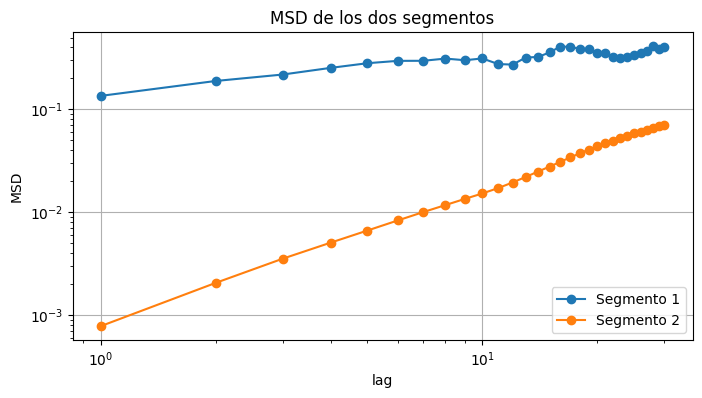

In [29]:
seg1 = x_task3[:cp_true]
seg2 = x_task3[cp_true:]

lags1, msd1 = empirical_msd(seg1, max_lag=30)
lags2, msd2 = empirical_msd(seg2, max_lag=30)

plt.loglog(lags1, msd1, 'o-', label="Segmento 1")
plt.loglog(lags2, msd2, 'o-', label="Segmento 2")
plt.title("MSD de los dos segmentos")
plt.xlabel("lag")
plt.ylabel("MSD")
plt.legend()
plt.show()

## 7. Análisis separado de los dos segmentos

### Comentario

En este ejemplo, la trayectoria ha sido construida mediante la concatenación de dos procesos estocásticos con propiedades distintas. En consecuencia, cada segmento presenta un comportamiento de difusión caracterizado por un exponente anómalo diferente.

La representación de la MSD en escala log-log permite analizar este comportamiento de forma cuantitativa. En particular, recordamos que:

$$
\mathrm{MSD}(t) = \left\langle (x(t+\tau) - x(t))^2 \right\rangle \propto \tau^\alpha
$$

Por lo tanto, la pendiente de la curva en escala log-log proporciona una estimación del exponente \(\alpha\).

En la figura obtenida se observa que:
- los dos segmentos presentan pendientes claramente distintas,
- lo que indica que corresponden a regímenes de difusión diferentes.

Este resultado confirma que la trayectoria contiene un **cambio de régimen (changepoint)**, lo cual reproduce de manera controlada el problema planteado en la Task 3.

Además, este análisis pone de manifiesto que:
- la segmentación de la trayectoria es necesaria para una correcta estimación de \($\alpha$\),
- ya que una estimación global ocultaría la heterogeneidad del proceso.

Este tipo de configuración constituye un primer paso fundamental antes de aplicar métodos automáticos de detección de cambios en trayectorias reales o simuladas.